<a href="https://colab.research.google.com/github/tisenres/amity-aiml303/blob/main/Building_and_Training_a_Simple_Transformer_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building and Training a Simple Transformer
## Implementing a basic Transformer for sequence tasks


## Welcome!
Welcome to this beginner-friendly lab. We will build a tiny Transformer encoder from scratch, step by step, in PyTorch.

### Learning objectives
- Understand attention in plain English.
- Build scaled dot-product attention.
- Build multi-head attention.
- Build one Transformer block and a tiny encoder.
- Train on a toy character dataset.
- Generate text and visualize loss/attention.

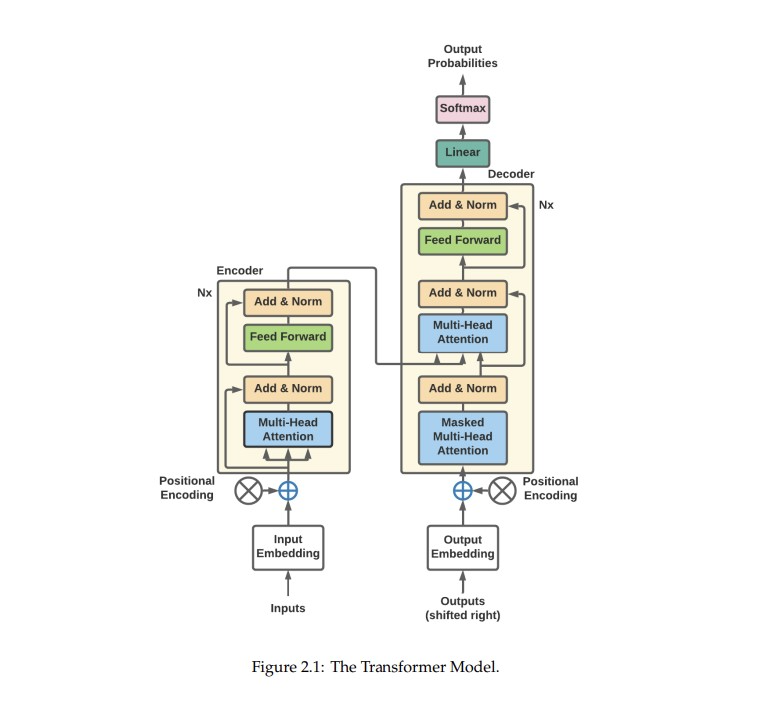

## 1) Prerequisites & Setup

In [1]:
# !pip install torch matplotlib numpy tqdm
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Everything is ready! ✅")
print("Using device:", device)

Everything is ready! ✅
Using device: cpu


Great job setting up! Seeds help reproducibility and device decides CPU/GPU execution.

## 2) Tutorial: Build a Simple Transformer from Scratch

In this tutorial, we move slowly and build one piece at a time.

### How to use this section
- Read each markdown explanation first.
- Then run the next code cell.
- If anything feels unclear, re-run and inspect shapes.

### Our build order
1. Scaled Dot-Product Attention (core math idea)
2. Multi-Head Attention (multiple attention views)
3. One Transformer Block (attention + feed-forward + residual + norm)
4. Tiny Encoder (stack blocks for sequence learning)
5. Tiny dataset and training loop
6. Inference and simple visualizations

### Attention idea (very simple)
When predicting the next character, the model asks: "Which earlier characters are important right now?"

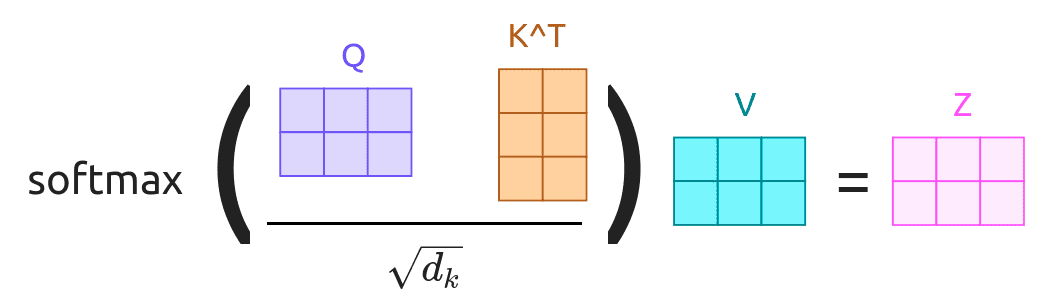

### Core equation
In plain English: compute similarity scores, normalize into probabilities, and use them to mix value vectors.

In [3]:
class ScaledDotProductAttention(nn.Module):
    def __init__(self):
        # nn.Module init so PyTorch can track this layer properly
        super().__init__()

    def forward(self, Q, K, V, mask=None):
        # Q, K, V expected shape:
        # (batch_size, n_heads, seq_len, head_dim)
        # We keep this format so each head computes attention independently.

        # head_dim = d_k in the attention formula
        d_k = Q.size(-1)

        # Step 1: raw similarity scores = Q * K^T
        # K is transposed on the last two dimensions so matrix multiply works.
        scores = torch.matmul(Q, K.transpose(-2, -1))

        # Step 2: scale scores by sqrt(d_k)
        # Why: keeps values in a stable range so softmax is not too sharp early.
        scores = scores / math.sqrt(d_k)

        # Step 3 (optional): apply mask
        # Where mask == 0, we place a very negative number so softmax -> ~0 there.
        # This is important for causal (no peeking future) behavior.
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        # Step 4: convert scores to probabilities along key dimension
        attn_weights = torch.softmax(scores, dim=-1)

        # Step 5: weighted sum of V vectors
        # Each query position gets a blended representation.
        output = torch.matmul(attn_weights, V)

        # Return both output and weights (weights help for visualization/debugging)
        return output, attn_weights

In [4]:
# Quick shape test
Q = torch.randn(2, 2, 4, 8)
K = torch.randn(2, 2, 4, 8)
V = torch.randn(2, 2, 4, 8)
attn = ScaledDotProductAttention()
out, w = attn(Q, K, V)
print(out.shape, w.shape)

torch.Size([2, 2, 4, 8]) torch.Size([2, 2, 4, 4])


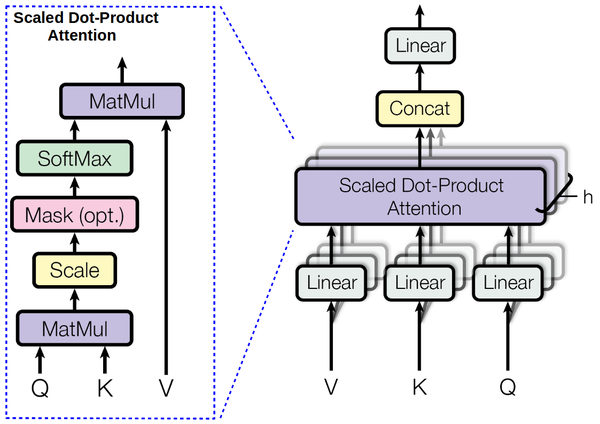

In [5]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()

        # Requirement: model dimension must split evenly across heads
        assert d_model % n_heads == 0

        # Store configuration
        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads

        # Linear layers to create Q, K, V from input embeddings
        # Each outputs size d_model, then we split into heads later.
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # Final output projection after head concatenation
        self.W_o = nn.Linear(d_model, d_model)

        # Reuse our single-head attention logic
        self.attn = ScaledDotProductAttention()

    def split_heads(self, x):
        # Input x shape: (batch, seq_len, d_model)
        b, t, _ = x.size()

        # Reshape into (batch, seq_len, n_heads, head_dim)
        x = x.view(b, t, self.n_heads, self.head_dim)

        # Transpose to (batch, n_heads, seq_len, head_dim)
        # This layout is convenient for attention computation per head.
        return x.transpose(1, 2)

    def combine_heads(self, x):
        # Input x shape: (batch, n_heads, seq_len, head_dim)
        b, h, t, d = x.size()

        # Move heads back after sequence dimension
        x = x.transpose(1, 2).contiguous()

        # Flatten heads into d_model: (batch, seq_len, h*d)
        x = x.view(b, t, h * d)
        return x

    def forward(self, x, mask=None):
        # Project input to Q, K, V spaces
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        # Split each into heads
        Q = self.split_heads(Q)
        K = self.split_heads(K)
        V = self.split_heads(V)

        # Run scaled dot-product attention for all heads
        out, w = self.attn(Q, K, V, mask)

        # Recombine heads back into one tensor
        out = self.combine_heads(out)

        # Final linear mixing
        out = self.W_o(out)

        return out, w

In [6]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model=32, n_heads=2, d_ff=64, dropout=0.1):
        super().__init__()

        # Sub-layer 1: self-attention
        self.mha = MultiHeadAttention(d_model, n_heads)

        # LayerNorm after attention residual path
        self.norm1 = nn.LayerNorm(d_model)

        # Sub-layer 2: small feed-forward network (position-wise MLP)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model),
        )

        # LayerNorm after FFN residual path
        self.norm2 = nn.LayerNorm(d_model)

        # Dropout helps regularization, kept small for tiny model
        self.drop = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # ---- Attention path ----
        # attention output keeps same shape as x: (batch, seq_len, d_model)
        attn_out, attn_w = self.mha(x, mask)

        # Residual connection + LayerNorm
        # "Residual" means we add original input x back in.
        x = self.norm1(x + self.drop(attn_out))

        # ---- Feed-forward path ----
        ffn_out = self.ffn(x)

        # Residual connection + LayerNorm again
        x = self.norm2(x + self.drop(ffn_out))

        return x, attn_w

In [7]:
class SimpleTransformerEncoder(nn.Module):
    def __init__(self, vocab_size, d_model=32, n_heads=2, d_ff=64, n_layers=1, dropout=0.1):
        super().__init__()

        # Converts token IDs -> dense vectors of length d_model
        self.embedding = nn.Embedding(vocab_size, d_model)

        # Stack of Transformer blocks
        self.layers = nn.ModuleList([
            TransformerBlock(d_model=d_model, n_heads=n_heads, d_ff=d_ff, dropout=dropout)
            for _ in range(n_layers)
        ])

        # Maps hidden states back to vocabulary logits for each position
        self.output = nn.Linear(d_model, vocab_size)

    def forward(self, x, mask=None, return_attn=False):
        # x shape: (batch, seq_len)

        # Step 1: token embedding
        h = self.embedding(x)

        # Step 2: pass through all Transformer blocks
        all_attn = []
        for layer in self.layers:
            h, w = layer(h, mask)
            all_attn.append(w)

        # Step 3: produce logits per token position
        logits = self.output(h)

        # Optional: return attention maps for visualization
        return (logits, all_attn) if return_attn else logits

## 3) Tiny Character Dataset

This section prepares simple data so training finishes quickly.

### Important beginner idea
Neural networks do not read raw text directly.  
They read integer IDs. So we convert characters -> numbers.

### Our next-token setup
- Input sequence: characters at positions `0..T-1`
- Target sequence: same text shifted by 1 position

This teaches the model to predict the next character at each step.

In [8]:
text = (
    "to be, or not to be: that is the question.\n"
    "whether tis nobler in the mind to suffer\n"
    "the slings and arrows of outrageous fortune.\n"
) * 30

chars = sorted(list(set(text)))
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}
vocab_size = len(chars)
encoded = [stoi[ch] for ch in text]

print("Vocab:", chars)
print("Vocab size:", vocab_size)

Vocab: ['\n', ' ', ',', '.', ':', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'i', 'l', 'm', 'n', 'o', 'q', 'r', 's', 't', 'u', 'w']
Vocab size: 23


In [9]:
class CharSeqDataset(Dataset):
    def __init__(self, token_ids, seq_len):
        # Full encoded text as integer token IDs
        self.token_ids = token_ids
        # Fixed training context window
        self.seq_len = seq_len

    def __len__(self):
        # Number of valid windows
        # If seq_len is 16, each item needs 17 tokens (16 input + next token target shift)
        return len(self.token_ids) - self.seq_len

    def __getitem__(self, idx):
        # Input chunk [idx : idx+seq_len]
        x = self.token_ids[idx:idx + self.seq_len]

        # Target chunk is shifted by one position
        y = self.token_ids[idx + 1:idx + self.seq_len + 1]

        # Return as long tensors (required by nn.Embedding and CrossEntropy targets)
        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)


def generate_causal_mask(seq_len, device):
    # Create lower-triangular matrix:
    # token i can only attend to tokens <= i (past and current, not future)
    mask = torch.tril(torch.ones(seq_len, seq_len, device=device))

    # Expand dims to match attention score broadcasting:
    # (1, 1, seq_len, seq_len)
    return mask.unsqueeze(0).unsqueeze(0)

In [10]:
# Tiny settings so this runs on normal laptops quickly
seq_len = 16
batch_size = 32

# Build dataset and dataloader
dataset = CharSeqDataset(encoded, seq_len)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Create a very small Transformer encoder
model = SimpleTransformerEncoder(
    vocab_size=vocab_size,  # number of possible output characters
    d_model=32,             # embedding/hidden size
    n_heads=2,              # number of attention heads
    d_ff=64,                # feed-forward hidden size
    n_layers=1,             # number of Transformer blocks
    dropout=0.1             # small regularization
).to(device)

# For next-token prediction over vocabulary IDs
criterion = nn.CrossEntropyLoss()

# Adam is a stable optimizer for beginners
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [11]:
epochs = 8
loss_history = []
model.train()

for epoch in range(1, epochs + 1):
    # Track average loss for this epoch
    running_loss = 0.0

    # Progress bar helps visualize learning progress
    pbar = tqdm(loader, desc=f"Epoch {epoch}/{epochs}", leave=False)

    for x, y in pbar:
        # Move input and labels to selected device
        x = x.to(device)
        y = y.to(device)

        # Causal mask prevents future-token cheating
        mask = generate_causal_mask(x.size(1), device)

        # Forward pass: logits shape (batch, seq_len, vocab_size)
        logits = model(x, mask=mask)

        # CrossEntropy expects:
        # logits: (N, C), targets: (N,)
        # So we flatten batch and time dims into N
        loss = criterion(logits.view(-1, vocab_size), y.view(-1))

        # Clear old gradients from previous step
        optimizer.zero_grad()

        # Backprop computes gradients
        loss.backward()

        # Optimizer updates weights
        optimizer.step()

        running_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    # Save epoch average loss for plotting
    avg_loss = running_loss / len(loader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch:02d} | Avg Loss: {avg_loss:.4f}")

Epoch 1/8:   0%|          | 0/121 [00:00<?, ?it/s]

Epoch 01 | Avg Loss: 2.0736


Epoch 2/8:   0%|          | 0/121 [00:00<?, ?it/s]

Epoch 02 | Avg Loss: 1.0353


Epoch 3/8:   0%|          | 0/121 [00:00<?, ?it/s]

...

Epoch 06 | Avg Loss: 0.4052


Epoch 7/8:   0%|          | 0/121 [00:00<?, ?it/s]

Epoch 07 | Avg Loss: 0.3737


Epoch 8/8:   0%|          | 0/121 [00:00<?, ?it/s]

Epoch 08 | Avg Loss: 0.3502


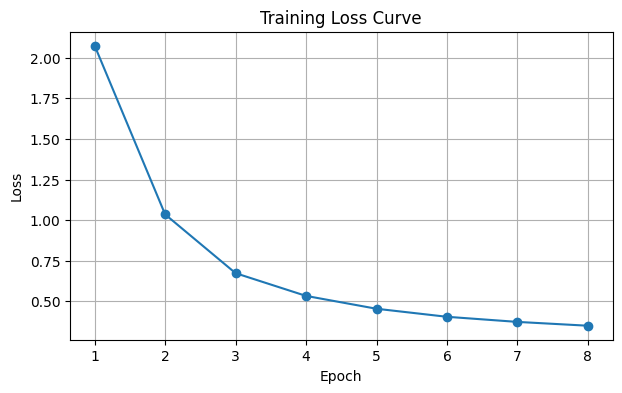

In [12]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker="o")
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [13]:
def generate_text(model, start_text, stoi, itos, seq_len=16, max_new_tokens=40, temperature=0.8):
    # Inference mode: disables dropout behavior
    model.eval()

    # Convert prompt text to token IDs
    ids = [stoi[ch] for ch in start_text]

    # Generate one token at a time
    for _ in range(max_new_tokens):
        # Keep only recent context window
        context = ids[-seq_len:]

        # Build model input with batch dimension = 1
        x = torch.tensor(context, dtype=torch.long, device=device).unsqueeze(0)

        # Build matching causal mask for current context length
        mask = generate_causal_mask(x.size(1), device)

        with torch.no_grad():
            logits = model(x, mask=mask)

        # Use the final position logits to choose next token
        next_logits = logits[0, -1] / temperature

        # Convert logits -> probabilities
        probs = torch.softmax(next_logits, dim=-1)

        # Sample from distribution (more creative than always argmax)
        next_id = torch.multinomial(probs, num_samples=1).item()
        ids.append(next_id)

    # Convert IDs back to characters
    return "".join(itos[i] for i in ids)


# Try multiple prompts to inspect model behavior
for prompt in ["to be", "the", "i"]:
    print("Prompt:", repr(prompt))
    print("Generated:", repr(generate_text(model, prompt, stoi, itos, seq_len=seq_len)))
    print("-" * 50)

Prompt: 'to be'
Generated: 'to be: that is iows noff o outrage.\ntus be, f'
--------------------------------------------------
Prompt: 'the'
Generated: 'ther is noble ings and arrows of outrageous'
--------------------------------------------------
Prompt: 'i'
Generated: 'in the s the question.\nwher nofor outhe s'
--------------------------------------------------


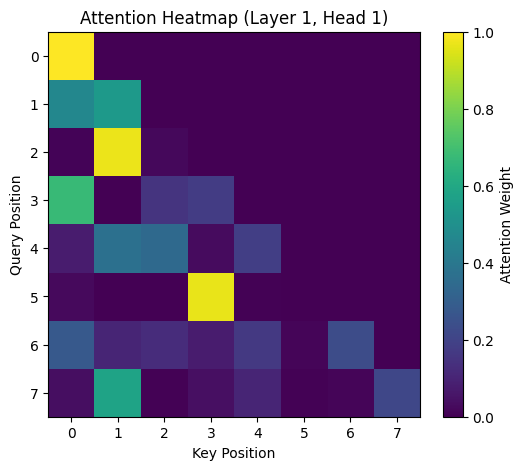

In [14]:
# Switch model to eval mode for consistent visualization
model.eval()

# Build one example sequence
example_text = "question"[:seq_len]
example_ids = torch.tensor([[stoi[ch] for ch in example_text]], dtype=torch.long, device=device)

# Causal mask for the same sequence length
example_mask = generate_causal_mask(example_ids.size(1), device)

with torch.no_grad():
    # Request attention maps from the model
    _, all_attn = model(example_ids, mask=example_mask, return_attn=True)

# all_attn[0] shape: (batch, heads, seq_len, seq_len)
# Select first sample and first head
attn_matrix = all_attn[0][0, 0].detach().cpu().numpy()

# Plot heatmap: brighter color means stronger attention weight
plt.figure(figsize=(6, 5))
plt.imshow(attn_matrix, cmap="viridis", aspect="auto")
plt.colorbar(label="Attention Weight")
plt.title("Attention Heatmap (Layer 1, Head 1)")
plt.xlabel("Key Position")
plt.ylabel("Query Position")
plt.show()

Great progress! You now have a complete mini Transformer training pipeline:
- data encoding,
- causal masking,
- forward pass,
- loss optimization,
- and learning curve tracking.

Next, we use the trained model for text generation and attention visualization.

# 4) Lab Tasks – Total 100 points

## Task 1 (50 points): Add Positional Encoding

### Rubric
- Correctness (30 pts)
- Clean code + comments (10 pts)
- Sequence length experiments (10 pts)

In [ ]:
def create_sinusoidal_positional_encoding(max_len, d_model):
    pe = torch.zeros(max_len, d_model)
    position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

    # TODO 1: apply sin to even dimensions
    pe[:, 0::2] = torch.sin(position * div_term)

    # TODO 2: apply cos to odd dimensions
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe

class SimpleTransformerEncoderWithPE(nn.Module):
    def __init__(self, vocab_size, d_model=32, n_heads=2, d_ff=64, n_layers=1, max_len=64, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.layers = nn.ModuleList([
            TransformerBlock(d_model=d_model, n_heads=n_heads, d_ff=d_ff, dropout=dropout)
            for _ in range(n_layers)
        ])
        self.output = nn.Linear(d_model, vocab_size)
        pe = create_sinusoidal_positional_encoding(max_len, d_model)
        self.register_buffer("pos_encoding", pe)

    def forward(self, x, mask=None):
        h = self.embedding(x)

        # TODO 3: add positional encoding to h
        seq_len_local = x.size(1)
        # Add the encoding (broadcasted across batch dimension)
        h = h + self.pos_encoding[:seq_len_local, :].unsqueeze(0)

        for layer in self.layers:
            h, _ = layer(h, mask)
        return self.output(h)

### Task 1 Starter TODO: Extra Guided Hints

- **TODO 1 (`sin` on even dims)**
  - Hint 1: Select even columns as `pe[:, 0::2]`.
  - Hint 2: Use `position * div_term` (broadcasts automatically).
  - Hint 3: Fill with `torch.sin(...)`.
  - Hint 4: Resulting slice should be `(max_len, d_model // 2)`.
- **TODO 2 (`cos` on odd dims)**
  - Hint 1: Select odd columns as `pe[:, 1::2]`.
  - Hint 2: Reuse same `position * div_term` angles.
  - Hint 3: Only switch function to `torch.cos(...)`.
- **TODO 3 (add positional encoding)**
  - Hint 1: Compute `seq_len_local = x.size(1)`.
  - Hint 2: Slice `self.pos_encoding[:seq_len_local]`.
  - Hint 3: `unsqueeze(0)` before adding to `h` for batch broadcasting.

Submission for Task 1: complete TODOs, run cells, and keep clear comments.

## Task 2 (50 points): Sequence Classification

Goal: predict one label for the full sequence.  
Label rule: class 1 if sequence contains 'abc', else class 0.

### Rubric
- Correctness (30 pts)
- Training/accuracy quality (10 pts)
- Clean code + comments (10 pts)

In [ ]:
def generate_classification_samples(n_samples=700, seq_len=12, alphabet="abcde"):
    sequences, labels = [], []
    for _ in range(n_samples):
        seq = "".join(random.choice(alphabet) for _ in range(seq_len))
        label = 1 if "abc" in seq else 0
        sequences.append(seq)
        labels.append(label)
    return sequences, labels


class SequenceClassificationDataset(Dataset):
    def __init__(self, sequences, labels, stoi_local):
        self.sequences = sequences
        self.labels = labels
        self.stoi_local = stoi_local

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        x = torch.tensor([self.stoi_local[ch] for ch in self.sequences[idx]], dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

In [ ]:
class TransformerSequenceClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=32, n_heads=2, d_ff=64, n_layers=1, n_classes=2, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.layers = nn.ModuleList([
            TransformerBlock(d_model=d_model, n_heads=n_heads, d_ff=d_ff, dropout=dropout)
            for _ in range(n_layers)
        ])
        self.classifier = nn.Linear(d_model, n_classes)

    def forward(self, x):
        h = self.embedding(x)
        for layer in self.layers:
            h, _ = layer(h, mask=None)

        # TODO 1: choose sequence representation
        # We use Mean Pooling over the sequence dimension
        seq_repr = h.mean(dim=1)

        # TODO 2: compute class logits
        logits = self.classifier(seq_repr)
        return logits

In [ ]:
cls_chars = sorted(set("abcde"))
cls_stoi = {ch: i for i, ch in enumerate(cls_chars)}
seqs, labels = generate_classification_samples(n_samples=700, seq_len=12, alphabet="abcde")
split_idx = int(0.8 * len(seqs))
train_ds = SequenceClassificationDataset(seqs[:split_idx], labels[:split_idx], cls_stoi)
val_ds = SequenceClassificationDataset(seqs[split_idx:], labels[split_idx:], cls_stoi)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

cls_model = TransformerSequenceClassifier(vocab_size=len(cls_stoi)).to(device)

# TODO 3: choose correct loss for classification
cls_criterion = nn.CrossEntropyLoss()
cls_optimizer = torch.optim.Adam(cls_model.parameters(), lr=1e-3)

def evaluate_acc(model, dl):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in dl:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total

for epoch in range(1, 7):
    cls_model.train()
    running = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        logits = cls_model(x)
        loss = cls_criterion(logits, y)
        cls_optimizer.zero_grad()
        loss.backward()
        cls_optimizer.step()
        running += loss.item()
    val_acc = evaluate_acc(cls_model, val_loader)
    print(f"Epoch {epoch:02d} | Loss {running/len(train_loader):.4f} | Val Acc {val_acc:.3f}")

### Task 2 Starter TODO: Extra Guided Hints
- **TODO 1 (choose sequence representation)**
  - Hint 1: Start with last token state: `h[:, -1, :]`.
  - Hint 2: Expected shape is `(batch, d_model)`.
  - Hint 3: Alternative is mean pooling: `h.mean(dim=1)`.
- **TODO 2 (compute logits)**
  - Hint 1: Pass representation through `self.classifier`.
  - Hint 2: Output should be raw logits of shape `(batch, 2)`.
  - Hint 3: Do **not** apply softmax before loss.
- **TODO 3 (pick classification loss)**
  - Hint 1: Labels are integer class IDs (`0` or `1`).
  - Hint 2: Use `nn.CrossEntropyLoss()` with raw logits.
  - Hint 3: If using BCE variants, you must change labels/output format (not needed here).

Submission for Task 2: complete TODOs and show final training/validation output.

# 5) Bonus: Theoretical Questions (10% extra credit)

### Q1
Why do we use multi-head attention instead of one head?

**Your answer:**
Multi-head attention allows the model to simultaneously attend to information from different representation subspaces at different positions. While a single head might focus on a specific syntactic relationship, multiple heads can capture various aspects like grammar, long-range context, and semantic meaning all at once.

### Q2
What would happen if positional encoding is removed completely?

**Your answer:**
Without positional encoding, the Transformer would treat the input sequence as a 'bag of words,' completely ignoring the order of tokens. Since the attention mechanism itself is permutation-invariant, the model would be unable to distinguish between 'the dog bit the man' and 'the man bit the dog.'

### Q3
Why is a Transformer usually faster to train than an RNN for long sequences?

**Your answer:**
Unlike RNNs, which must process tokens sequentially and wait for previous hidden states, Transformers allow for massive parallelization during training. Because each token can attend to all others simultaneously, the model can utilize modern GPU hardware much more efficiently, avoiding the sequential bottleneck.